In [3]:
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp

In [4]:
np.random.seed(33550336)
rng = np.random.default_rng()

In [5]:
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split

In [6]:
X, y = fetch_openml('mnist_784', version=1, return_X_y=True, as_frame=False)
xtr, xte, ytr, yte = train_test_split(X, y, test_size = 10000/70000, random_state = 33550336, stratify = y)
moo = np.mean(xtr, axis = 0)
xc = xtr - moo

In [7]:
u, sig, vt = np.linalg.svd(xc, full_matrices=False)

In [8]:
big = sig ** 2
rig = (big/np.sum(big))
cig = np.cumsum(rig)
iig = np.argmax(cig > 0.95)
iig

np.int64(153)

In [9]:
vk = vt[:iig].T
z = xc @ vk
xhat = z @ vk.T
xhat += moo

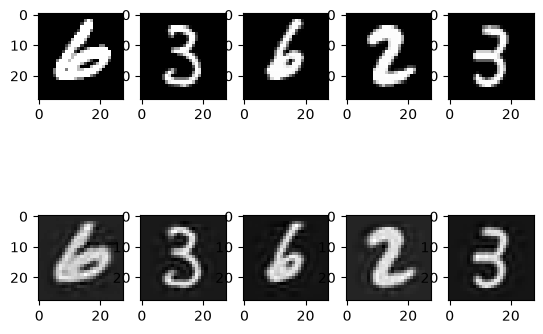

In [10]:
fige, axes = plt.subplots(2, 5)
for i in range(5):
    axes[0, i].imshow(xtr[i].reshape(28, 28), cmap = "grey")
    axes[1, i].imshow(xhat[i].reshape(28, 28), cmap = "grey")

In [11]:
vk = vt[:2].T
xte = xte - moo
xt = xte[:1000]
z = xt @ vk

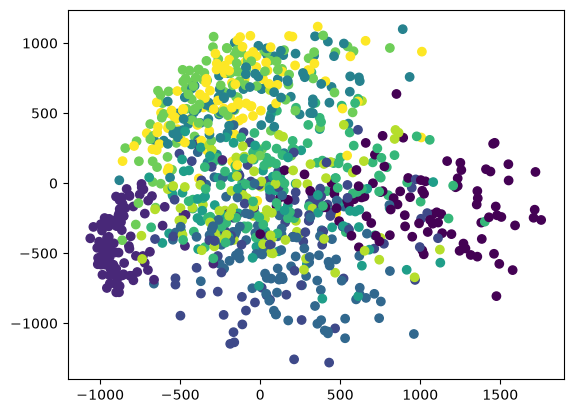

In [12]:
yplot = yte[:1000].astype(int)
plt.scatter(x = z[:, 0], y = z[:, 1], c = yplot)

In [13]:
from sklearn.manifold import TSNE

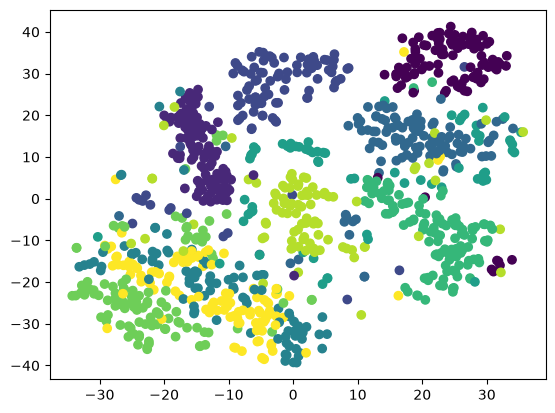

In [14]:
tsne = TSNE(n_components=2, perplexity=30, random_state = 33550336)
zt = tsne.fit_transform(xt)
plt.scatter(x = zt[:, 0], y = zt[:, 1], c = yplot)

In [21]:
from sklearn.datasets import load_iris
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.decomposition import PCA

In [16]:
iris = load_iris()
x = iris.data
y = iris.target

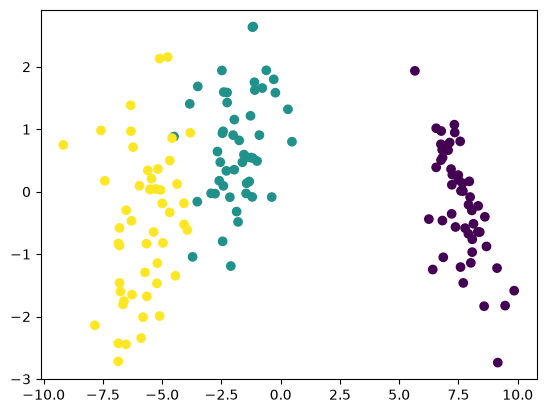

In [20]:
lda = LinearDiscriminantAnalysis(n_components = 2)
xt = lda.fit_transform(x, y)
plt.scatter(x = xt[:, 0], y = xt[:, 1], c = y)

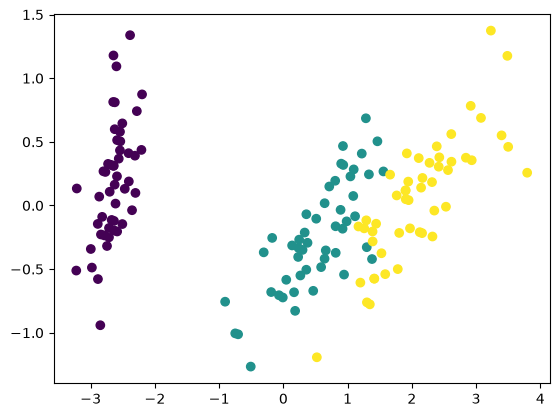

In [24]:
pca = PCA(n_components = 2)
pf = pca.fit_transform(x)
plt.scatter(x = pf[:, 0], y = pf[:, 1], c = y)